Kolom dataset:
Index(['timestamp', 'value', 'label', 'KPI ID'], dtype='object')

Contoh data:


,timestamp,value,label,KPI ID
0,1493568000,1.901639,0,02e99bd4f6cfb33f
1,1493568060,1.786885,0,02e99bd4f6cfb33f
2,1493568120,2.000000,0,02e99bd4f6cfb33f
3,1493568180,1.885246,0,02e99bd4f6cfb33f
4,1493568240,1.819672,0,02e99bd4f6cfb33f



Statistik Deskriptif:


,value
count,2.476315e+06
mean,1.080211e+08
std,3.196926e+08
min,-4.546069e+00
25%,3.700000e+00
50%,1.293438e+03
75%,2.523000e+03
max,1.608813e+09


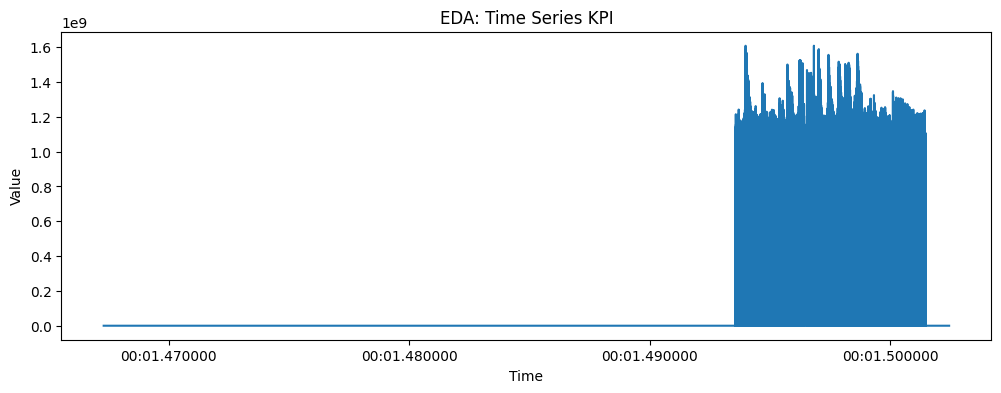

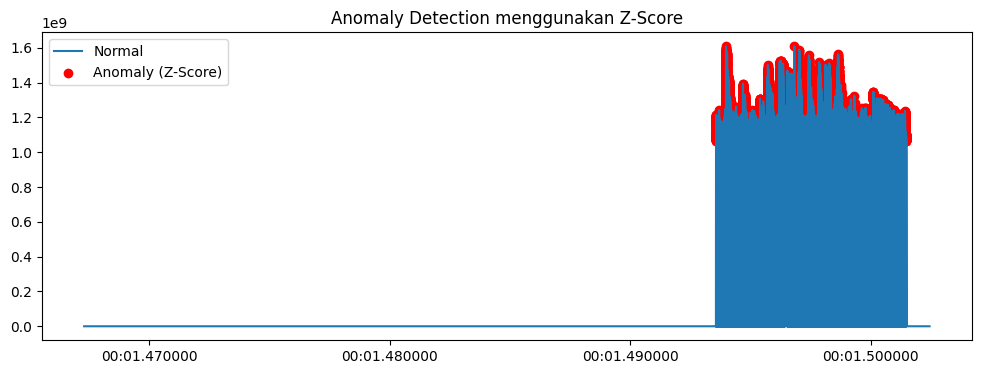

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


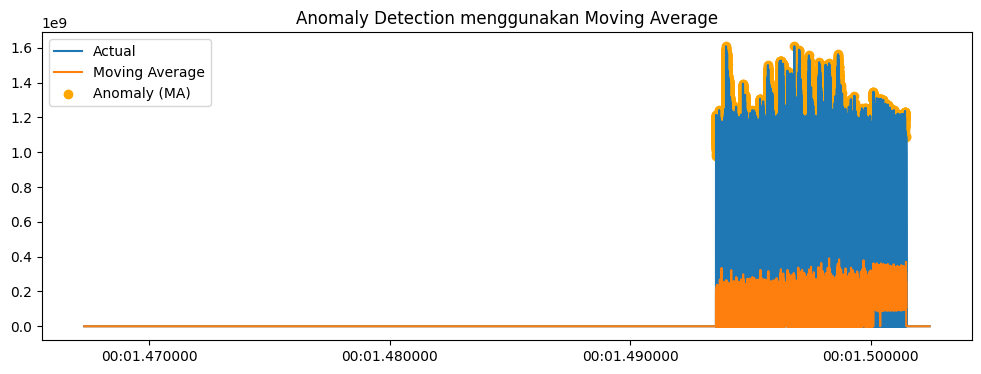


Perbandingan Jumlah Anomali:


,Method,Anomaly Count
0,Z-Score,100096
1,Moving Average,84165


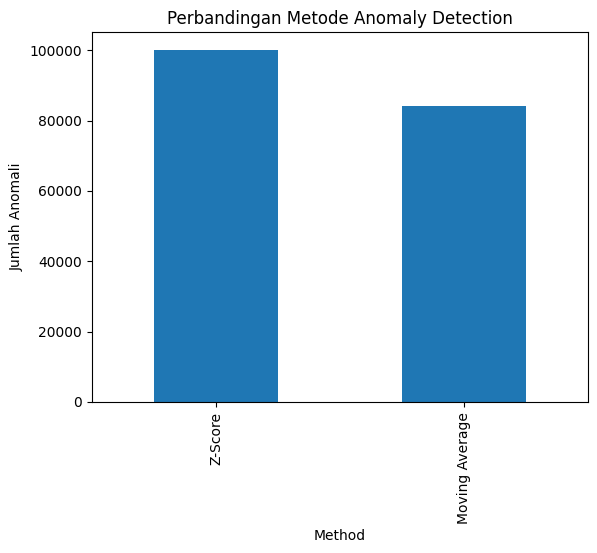

KESIMPULAN SINGKAT:
- Z-Score lebih sensitif mendeteksi anomali dibanding Moving Average.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. LOAD DATASET
df = pd.read_csv("train.csv")

# Tampilkan struktur data
print("Kolom dataset:")
print(df.columns)
print("\nContoh data:")
display(df.head())


# 2. PREPROCESSING
# Ubah timestamp ke datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Urutkan berdasarkan waktu
df = df.sort_values('timestamp')

# Ambil kolom nilai KPI
value_col = 'value'   # <- jika berbeda, ganti sesuai dataset

# Hapus missing value
df = df.dropna(subset=[value_col])

# 3. EDA (ExplORATORY DATA ANALYSIS)
print("\nStatistik Deskriptif:")
display(df[value_col].describe())

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df[value_col])
plt.title("EDA: Time Series KPI")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# 4. MODEL 1: Z-SCORE
mean = df[value_col].mean()
std = df[value_col].std()

df['z_score'] = (df[value_col] - mean) / std

z_threshold = 3
df['anomaly_zscore'] = np.abs(df['z_score']) > z_threshold

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df[value_col], label='Normal')
plt.scatter(
    df[df['anomaly_zscore']]['timestamp'],
    df[df['anomaly_zscore']][value_col],
    color='red',
    label='Anomaly (Z-Score)'
)
plt.legend()
plt.title("Anomaly Detection menggunakan Z-Score")
plt.show()

# 5. MODEL 2: MOVING AVERAGE
window = 20
df['moving_avg'] = df[value_col].rolling(window).mean()
df['residual'] = df[value_col] - df['moving_avg']

ma_threshold = 3 * df['residual'].std()
df['anomaly_ma'] = np.abs(df['residual']) > ma_threshold

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df[value_col], label='Actual')
plt.plot(df['timestamp'], df['moving_avg'], label='Moving Average')
plt.scatter(
    df[df['anomaly_ma']]['timestamp'],
    df[df['anomaly_ma']][value_col],
    color='orange',
    label='Anomaly (MA)'
)
plt.legend()
plt.title("Anomaly Detection menggunakan Moving Average")
plt.show()

# 6. MODEL COMPARISON
z_count = df['anomaly_zscore'].sum()
ma_count = df['anomaly_ma'].sum()

comparison = pd.DataFrame({
    'Method': ['Z-Score', 'Moving Average'],
    'Anomaly Count': [z_count, ma_count]
})

print("\nPerbandingan Jumlah Anomali:")
display(comparison)

comparison.plot(
    x='Method',
    y='Anomaly Count',
    kind='bar',
    legend=False,
    title='Perbandingan Metode Anomaly Detection'
)
plt.ylabel("Jumlah Anomali")
plt.show()

# 7. KESIMPULAN OTOMATIS (OPSIONAL)
print("KESIMPULAN SINGKAT:")
if z_count > ma_count:
    print("- Z-Score lebih sensitif mendeteksi anomali dibanding Moving Average.")
else:
    print("- Moving Average lebih stabil dibanding Z-Score.")
